In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [3]:
msturing100Mclustered_path = "/dataset/gp-ann-inserts/results/msturing100Mclustered_runbook_results_nprobe5.csv"
msturing100Mclustered = pd.read_csv(msturing100Mclustered_path)

In [4]:
shard_cols = ["shard_0_size","shard_1_size","shard_2_size","shard_3_size","shard_4_size","shard_5_size","shard_6_size","shard_7_size","shard_8_size","shard_9_size"]

In [5]:
msturing100Mclustered["gini"] = msturing100Mclustered[shard_cols].apply(lambda row: gini(row.values), axis=1)
msturing100Mclustered["cv"] = msturing100Mclustered[shard_cols].std(axis=1) / msturing100Mclustered[shard_cols].mean(axis=1)


In [6]:
msturing100Mshift_path = "/dataset/gp-ann-inserts/results/msturing100Mshift_runbook_results_nprobe5.csv"
msturing100Mshift = pd.read_csv(msturing100Mshift_path)

In [7]:
msturing100Mshift["gini"] = msturing100Mshift[shard_cols].apply(lambda row: gini(row.values), axis=1)
msturing100Mshift["cv"] = msturing100Mshift[shard_cols].std(axis=1) / msturing100Mshift[shard_cols].mean(axis=1)

In [8]:
msturing100Mrandom_path = "/dataset/gp-ann-inserts/results/msturing100Mrandom_runbook_results_nprobe5.csv"
msturing100Mrandom = pd.read_csv(msturing100Mrandom_path)

In [13]:
msturing100Mrandom[shard_cols]

,shard_0_size,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size
0,14090,13676,13093,12780,14013,13952,14386,13787,13506,13729
1,14090,13676,13093,12780,14013,13952,14386,13787,13506,13729
2,17940,17451,16551,16104,17612,17531,17664,17350,17067,17650
3,17940,17451,16551,16104,17612,17531,17664,17350,17067,17650
4,23486,23125,21636,21035,23033,22882,22742,22846,22376,23494
...,...,...,...,...,...,...,...,...,...,...
1275,10418371,10358041,9598690,9363606,10242976,9913796,9284088,9990204,10039483,10790589
1276,10418371,10358041,9598690,9363606,10242976,9913796,9284088,9990204,10039483,10790589
1277,10418371,10358041,9598690,9363606,10242976,9913796,9284088,9990204,10039483,10790589
1278,10418371,10358041,9598690,9363606,10242976,9913796,9284088,9990204,10039483,10790589


In [9]:
msturing100Mrandom["gini"] = msturing100Mrandom[shard_cols].apply(lambda row: gini(row.values), axis=1)
msturing100Mrandom["cv"] = msturing100Mrandom[shard_cols].std(axis=1) / msturing100Mrandom[shard_cols].mean(axis=1)

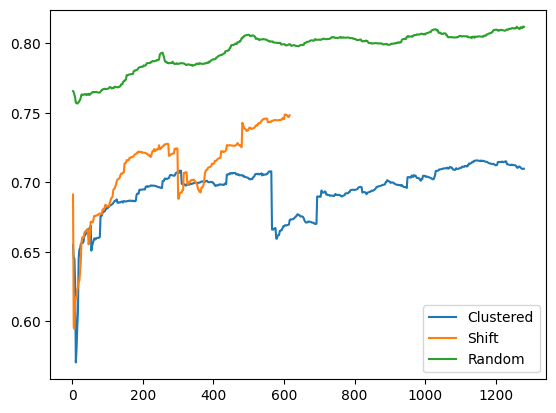

In [10]:
plt.plot(msturing100Mclustered[msturing100Mclustered["operation"] == "SEARCH"]["step"],
        msturing100Mclustered[msturing100Mclustered["operation"] == "SEARCH"]["recall@10"], label="Clustered")
plt.plot(msturing100Mshift[msturing100Mshift["operation"] == "SEARCH"]["step"],
         msturing100Mshift[msturing100Mshift["operation"] == "SEARCH"]["recall@10"], label="Shift")

plt.plot(msturing100Mrandom[msturing100Mrandom["operation"] == "SEARCH"]["step"],
         msturing100Mrandom[msturing100Mrandom["operation"] == "SEARCH"]["recall@10"], label="Random")
plt.legend()

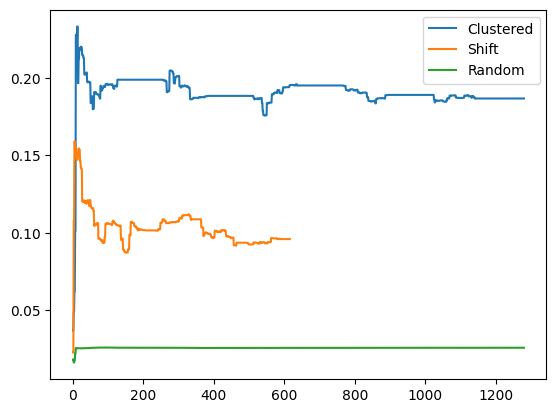

In [11]:
plt.plot(msturing100Mclustered["step"], msturing100Mclustered["gini"], label="Clustered")
plt.plot(msturing100Mshift["step"], msturing100Mshift["gini"], label="Shift")
plt.plot(msturing100Mrandom["step"], msturing100Mrandom["gini"], label="Random")
plt.legend()

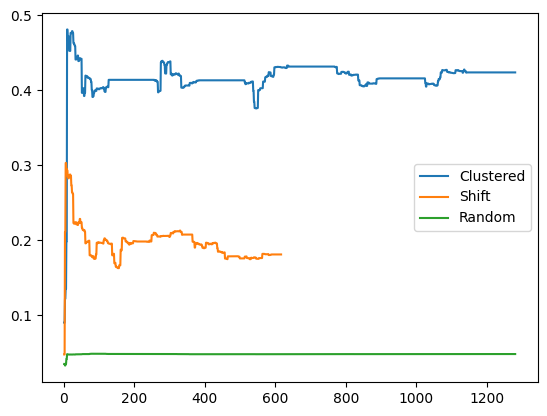

In [12]:
plt.plot(msturing100Mclustered["step"], msturing100Mclustered["cv"], label="Clustered")
plt.plot(msturing100Mshift["step"], msturing100Mshift["cv"], label="Shift")
plt.plot(msturing100Mrandom["step"], msturing100Mrandom["cv"], label="Random")
plt.legend()

In [ ]:
# todo: iterate over all nprobes and plot recall vs qps for each of the runbooks
# and recall vs nprobe ==> need to search more to achieve the equivalent recall